# Phase 2: Feature Analysis and Data Preparation

Goals:
1. Feature-level statistics and characterization
2. Zero-variance and low-variance feature review
3. Distribution analysis across relevance labels 
4. Feature normalization strategy planning
5. Query-level feature behavior analysis
6. Preparation for modeling (pointwise, pairwise, listwise)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

#Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',100)
pd.set_option('display.float_format','{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']=100

#Setup paths
PROJECT_ROOT=Path.cwd().parent
DATA_PROCESSED=PROJECT_ROOT/'data'/'processed'

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {DATA_PROCESSED}")

Project root: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding
Processed data directory: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed


# Loading Processed Data from Phase 1

In [12]:
#Loading the processed data from Phase 1
train_file=DATA_PROCESSED/'fold1_train_processed.csv'
query_stats_file=DATA_PROCESSED/'fold1_train_query_stats.csv'

print(f"Loading training data from: {train_file}")
df=pd.read_csv(train_file)

print(f"Loading query statistics from: {query_stats_file}")
query_stats=pd.read_csv(query_stats_file)

print(f"\n Data loaded successfully")
print(f"Training data shape: {df.shape}")
print(f"Query statistics shape: {query_stats.shape}")

#Identifying feature columns
feature_cols=[col for col in df.columns if col.startswith('f') and col[1:].isdigit()]
feature_cols=sorted(feature_cols,key=lambda x: int(x[1:]))
num_features=len(feature_cols)

print(f"\n Number of features: {num_features}")
print(f"Features: {feature_cols[0]} to {feature_cols[-1]}")

#Quick data overview
print(f'\n Unique queries: {df['qid'].nunique()}')
print(f"Total documents: {len(df)}")
print(f"Label distribution:")
for label, count in df['label'].value_counts().sort_index().items():
    print(f"Label {label}: {count} ({100*count/len(df):.2f}%)")

Loading training data from: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_processed.csv
Loading query statistics from: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_query_stats.csv

 Data loaded successfully
Training data shape: (42158, 49)
Query statistics shape: (1017, 9)

 Number of features: 46
Features: f1 to f46

 Unique queries: 1017
Total documents: 42158
Label distribution:
Label 0: 31585 (74.92%)
Label 1: 8388 (19.90%)
Label 2: 2185 (5.18%)


# 1. Feature-Level Statistics

Computing comprehensive statistics for each feature to understand:
- Centrel tendency (mean,median)
- Spread (std, min, max, IQR)
- Sparsity (zeros, near-zeros)
- Variance characteristics

In [13]:
print("="*60)
print("TASK 1: FEATURE-LEVEL STATISTICS")
print("="*60)

#Computing comprehensive statistics for each feature
feature_stats=pd.DataFrame(index=feature_cols)

for feat in feature_cols:
    values=df[feat]

    #Basic statistics
    feature_stats.loc[feat, 'mean']=values.mean()
    feature_stats.loc[feat, 'std']=values.std()
    feature_stats.loc[feat, 'min']=values.min()
    feature_stats.loc[feat, 'max']=values.max()
    feature_stats.loc[feat, 'median']=values.median()
    feature_stats.loc[feat, 'q25']=values.quantile(0.25)
    feature_stats.loc[feat, 'q75']=values.quantile(0.75)

    #Sparsity metrics
    feature_stats.loc[feat, 'num_zeros']=(values==0).sum()
    feature_stats.loc[feat, 'pct_zeros']=100*(values==0).sum()/len(values)
    feature_stats.loc[feat, 'num_missing']=values.isna().sum()

    #Distribution characteristics
    feature_stats.loc[feat, 'skewness']=stats.skew(values.dropna())
    feature_stats.loc[feat, 'kurtosis']=stats.kurtosis(values.dropna())

    #Variance classification
    feature_stats.loc[feat, 'variance']=values.var()
    feature_stats.loc[feat, 'coef_variation']=values.std()/values.mean() if values.mean()!=0 else np.inf
    #using infinity to handle zero by infinity as mean can be 0 in some cases

    #unique values
    feature_stats.loc[feat, 'num_unique']=values.nunique()

print("\n Computed statistics for all features")
print(f"\n Feature Statistics Summary (first 10 features):")
display(feature_stats[['mean','std','min','max','pct_zeros']].head(10))

TASK 1: FEATURE-LEVEL STATISTICS

 Computed statistics for all features

 Feature Statistics Summary (first 10 features):


,mean,std,min,max,pct_zeros
f1,0.1630,0.2366,0.0000,1.0000,4.9718
f2,0.1376,0.2495,0.0000,1.0000,62.7591
f3,0.2520,0.3411,0.0000,1.0000,56.7555
f4,0.1424,0.3085,0.0000,1.0000,79.4796
f5,0.1667,0.2366,0.0000,1.0000,4.2436
f6,0.0000,0.0000,0.0000,0.0000,100.0000
f7,0.0000,0.0000,0.0000,0.0000,100.0000
f8,0.0000,0.0000,0.0000,0.0000,100.0000
f9,0.0000,0.0000,0.0000,0.0000,100.0000
f10,0.0000,0.0000,0.0000,0.0000,100.0000


In [14]:
display(feature_stats[['skewness','kurtosis','variance','coef_variation','num_unique']].head(10))

,skewness,kurtosis,variance,coef_variation,num_unique
f1,2.1676,4.1743,0.0560,1.4512,21877.0000
f2,2.1259,3.9610,0.0622,1.8134,349.0000
f3,1.0490,-0.2573,0.1163,1.3534,86.0000
f4,2.0249,2.6372,0.0952,2.1670,22.0000
f5,2.1452,4.0743,0.0560,1.4190,22492.0000
f6,NaN,NaN,0.0000,inf,1.0000
f7,NaN,NaN,0.0000,inf,1.0000
f8,NaN,NaN,0.0000,inf,1.0000
f9,NaN,NaN,0.0000,inf,1.0000
f10,NaN,NaN,0.0000,inf,1.0000


**We will be using skewness, kurtosis and zero variance later**

## 1.1 Summary Statistics Overview

In [15]:
print("\n Global Feature Space Characteristics:")
print("="*60)
print(f"Mean feature mean: {feature_stats['mean'].mean():.4f}")
print(f"Mean feature std: {feature_stats['std'].mean():.4f}")
print(f"Mean sparsity (% zeros): {feature_stats['pct_zeros'].mean():.2f}%")
print(f"\n Features with >50% zeros: {(feature_stats['pct_zeros']>50).sum()}")
print(f"Features with >90% zeros: {(feature_stats['pct_zeros']>90).sum()}")

#Displaying full statistics for highly sparse features
highly_sparse=feature_stats[feature_stats['pct_zeros']>50].sort_values('pct_zeros', ascending=False)
if len(highly_sparse)>0:
    print(f"\n Highly Sparse Features (>50% zeros):")
    display(highly_sparse[['mean', 'std', 'pct_zeros', 'num_unique']])


 Global Feature Space Characteristics:
Mean feature mean: 0.2372
Mean feature std: 0.2406
Mean sparsity (% zeros): 43.69%

 Features with >50% zeros: 24
Features with >90% zeros: 6

 Highly Sparse Features (>50% zeros):


,mean,std,pct_zeros,num_unique
f6,0.0000,0.0000,100.0000,1.0000
f9,0.0000,0.0000,100.0000,1.0000
f8,0.0000,0.0000,100.0000,1.0000
f7,0.0000,0.0000,100.0000,1.0000
f10,0.0000,0.0000,100.0000,1.0000
f46,0.0000,0.0049,99.9976,2.0000
f35,0.0813,0.2497,83.2298,2931.0000
f36,0.0776,0.2359,83.2203,3041.0000
f34,0.0805,0.2361,82.8052,3396.0000
f14,0.1313,0.2928,79.4796,1363.0000


We treated each feature (f1...f46) like one "item" and asked on average, what is a feature's mean, std, etc? We took  global perspective here.

We then extracted the subset of features with >50% zeros and sorted them by sparcity. 

# 2. Zero-variance and Low-variance Feature Review

Decision Framework:
- Zero-variance features: No information, candidates for removal
- Near-zero-variance features: May have information but need careful consideration

In [16]:
print("="*60)
print("TASK 2: ZERO-VARIANCE AND LOW VARIANCE FEATURE REVIEW")
print("="*60)

#Identify zero-variance features
zero_var_features=feature_stats[feature_stats['variance']==0].index.tolist()
near_zero_var_features=feature_stats[(feature_stats['variance']>0)&(feature_stats['variance']<0.01)].index.tolist()

print(f"\n 1. Zero-Variance Features")
print(f"Count: {len(zero_var_features)}")
if zero_var_features:
    print(f"Features: {zero_var_features}")
    print(f"\n Details:")
    display(feature_stats.loc[zero_var_features, ['mean','std','min','max','num_unique']])
    print(f"\n Decision: These features provide NO information in Fold1 training data.")
    print(f"Recommendation: Considering removal, but will verify behavior in other folds first.")
else:
    print(f"No zero-variance features detected")

print(f"\n 2. Near-zero-variance features (variance < 0.01)")
print(f"Count: {len(near_zero_var_features)}")
if near_zero_var_features:
    print(f"Features: {near_zero_var_features}")
    print(f"\n Details: ")
    display(feature_stats.loc[near_zero_var_features, ['mean','std','min','max','num_unique']])
    print(f"\n Decision: These features have minimal variance.")
    print(f" Recommendation: Will monitor during modeling, may need removal if problematic.")
else:
    print(f"No near-zero-variance features detected")

#Low variance threshold analysis
print(f"\n 3. Variance distribution analysis")
variance_thresholds=[0.001,0.01,0.1,1.0]
for threshold in variance_thresholds:
    count=(feature_stats['variance']<threshold).sum()
    print(f"Features with variance < {threshold}:{count} ({100*count/num_features:.1f}%)")

TASK 2: ZERO-VARIANCE AND LOW VARIANCE FEATURE REVIEW

 1. Zero-Variance Features
Count: 5
Features: ['f6', 'f7', 'f8', 'f9', 'f10']

 Details:


,mean,std,min,max,num_unique
f6,0.0000,0.0000,0.0000,0.0000,1.0000
f7,0.0000,0.0000,0.0000,0.0000,1.0000
f8,0.0000,0.0000,0.0000,0.0000,1.0000
f9,0.0000,0.0000,0.0000,0.0000,1.0000
f10,0.0000,0.0000,0.0000,0.0000,1.0000



 Decision: These features provide NO information in Fold1 training data.
Recommendation: Considering removal, but will verify behavior in other folds first.

 2. Near-zero-variance features (variance < 0.01)
Count: 1
Features: ['f46']

 Details: 


,mean,std,min,max,num_unique
f46,0.0000,0.0049,0.0000,1.0000,2.0000



 Decision: These features have minimal variance.
 Recommendation: Will monitor during modeling, may need removal if problematic.

 3. Variance distribution analysis
Features with variance < 0.001:6 (13.0%)
Features with variance < 0.01:6 (13.0%)
Features with variance < 0.1:40 (87.0%)
Features with variance < 1.0:46 (100.0%)


## 2.1 Variance Distribution Visualization

We need to plot variance on a log scale because variance values can span orders of magnitude. For example, values can differ by factors of 10, not by small increments. 0.1 vs 0.01 -> 10x difference, 0.01 vs 0.0001 -> 100x difference, 0.1 vs 0.000001 -> 100,000x. Those differences are huge numerically, but visually they don't seem much of a difference on a normal scale.

Variance is the square of std,so everything blows up or collapses. So log10(variance) asks how many zeros after the decimal point. So, the differneces become visible

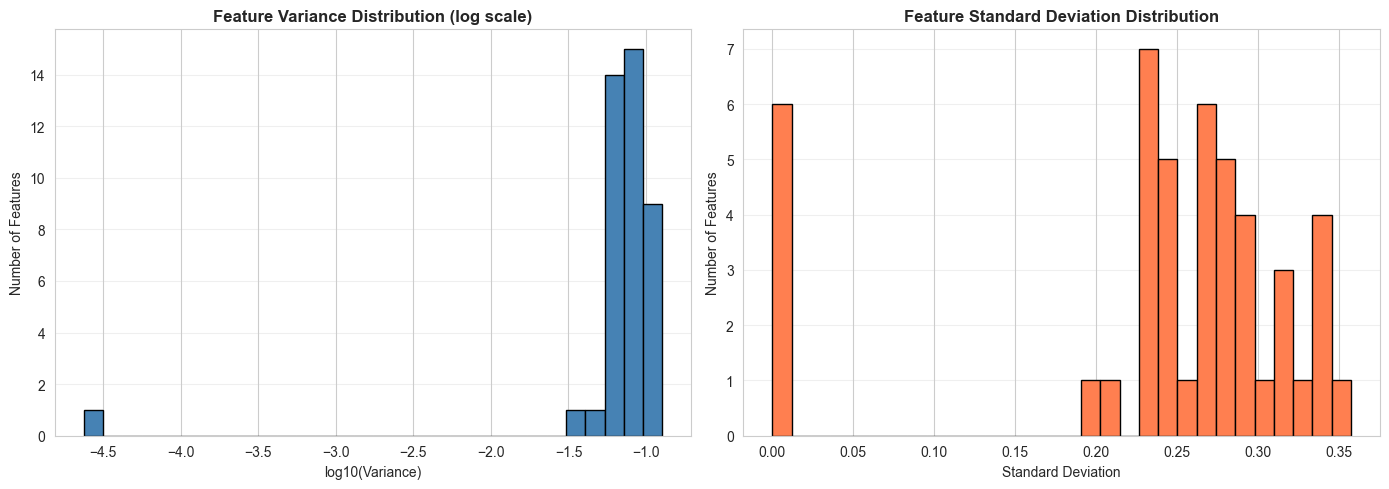

In [17]:
fig, axes=plt.subplots(1,2, figsize=(14,5))

#Plot 1: Variance distribution (log scale)
non_zero_var=feature_stats[feature_stats['variance']>0]['variance']
#Excluding the ones with variance=0 because log10(0) is undefined
axes[0].hist(np.log10(non_zero_var + 1e-10), bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('log10(Variance)')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Feature Variance Distribution (log scale)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

#Plot 2: Standard deviation distribution
axes[1].hist(feature_stats['std'], bins=30, color='coral', edgecolor='black')
axes[1].set_xlabel('Standard Deviation')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Standard Deviation Distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The first plot shows that the most non-constant features live on similar variance scales. Only one feature is near-degenerate but not constant. There is no chaotic spread across many orders of magnitude.


The second plot shows that aside from constant features, most features have comparable scale. We're not dealing with wildly mismatched feature magnitudes.

# 3. Distribution Analysis

Examining feature distributions to identify:
- skewed distributions
- heavy-tailed distributions
- multi-modal distributions
- differences across relevance labels

In [ ]:
print("="*60)
print("TASK 3: DISTRIBUTION ANALYSIS")
print("="*60)

#Identifying features with extreme skewness or kurtosis
highly_skewed=feature_stats[np.abs(feature_stats['skewness'])>2].index.tolist() 
#np.abs because we care about both left and right skew
heavy_tailed=feature_stats[feature_stats['kurtosis']>5].index.tolist()

print(f"\n 1. Distribution characteristics")
print(f"Highly skewed features (|skew|>2):{len(highly_skewed)}")
print(f"Heavy-tailed features (kurtosis>5):{len(heavy_tailed)}")

if highly_skewed:
    print(f"\n Highly skewed features: {highly_skewed[:10]}{'...'if len(highly_skewed)>10 else ''}")
    print(f"Note: Skewed features may benefit from log transformation")

#Distribution summary
print(f"\n 2. Skewness and kurtosis summary")
print(f" Mean skewness: {feature_stats['skewness'].mean():.4f}")
print(f"Mean kurtosis:{feature_stats['kurtosis'].mean():.4f}")
print(f"Features with near-normal distribution (|skew|<0.5):{(np.abs(feature_stats['skewness'])<0.5).sum()}")

TASK 3: DISTRIBUTION ANALYSIS

 1. Distribution characteristics
Highly skewed features (|skew|>2):15
Heavy-tailed features (kurtosis>5):6

 Highly skewed features: ['f1', 'f2', 'f4', 'f5', 'f12', 'f14', 'f16', 'f20', 'f34', 'f35']...
Note: Skewed features may benefit from log transformation

 2. Skewness and kurtosis summary
 Mean skewness: 6.2966
Mean kurtosis:1030.1606
Features with near-normal distribution (|skew|<0.5):7


**Above, log transformation for skewed features is just a suggestion not a step. We will most likely do per-query normalization, so a log transform globally may not be necessary.**

## 3.1 Sample Feature Distributions

We are visualizing a representative sample of features to understand typical distributions

Visualizing sample features: ['f1', 'f2', 'f3']


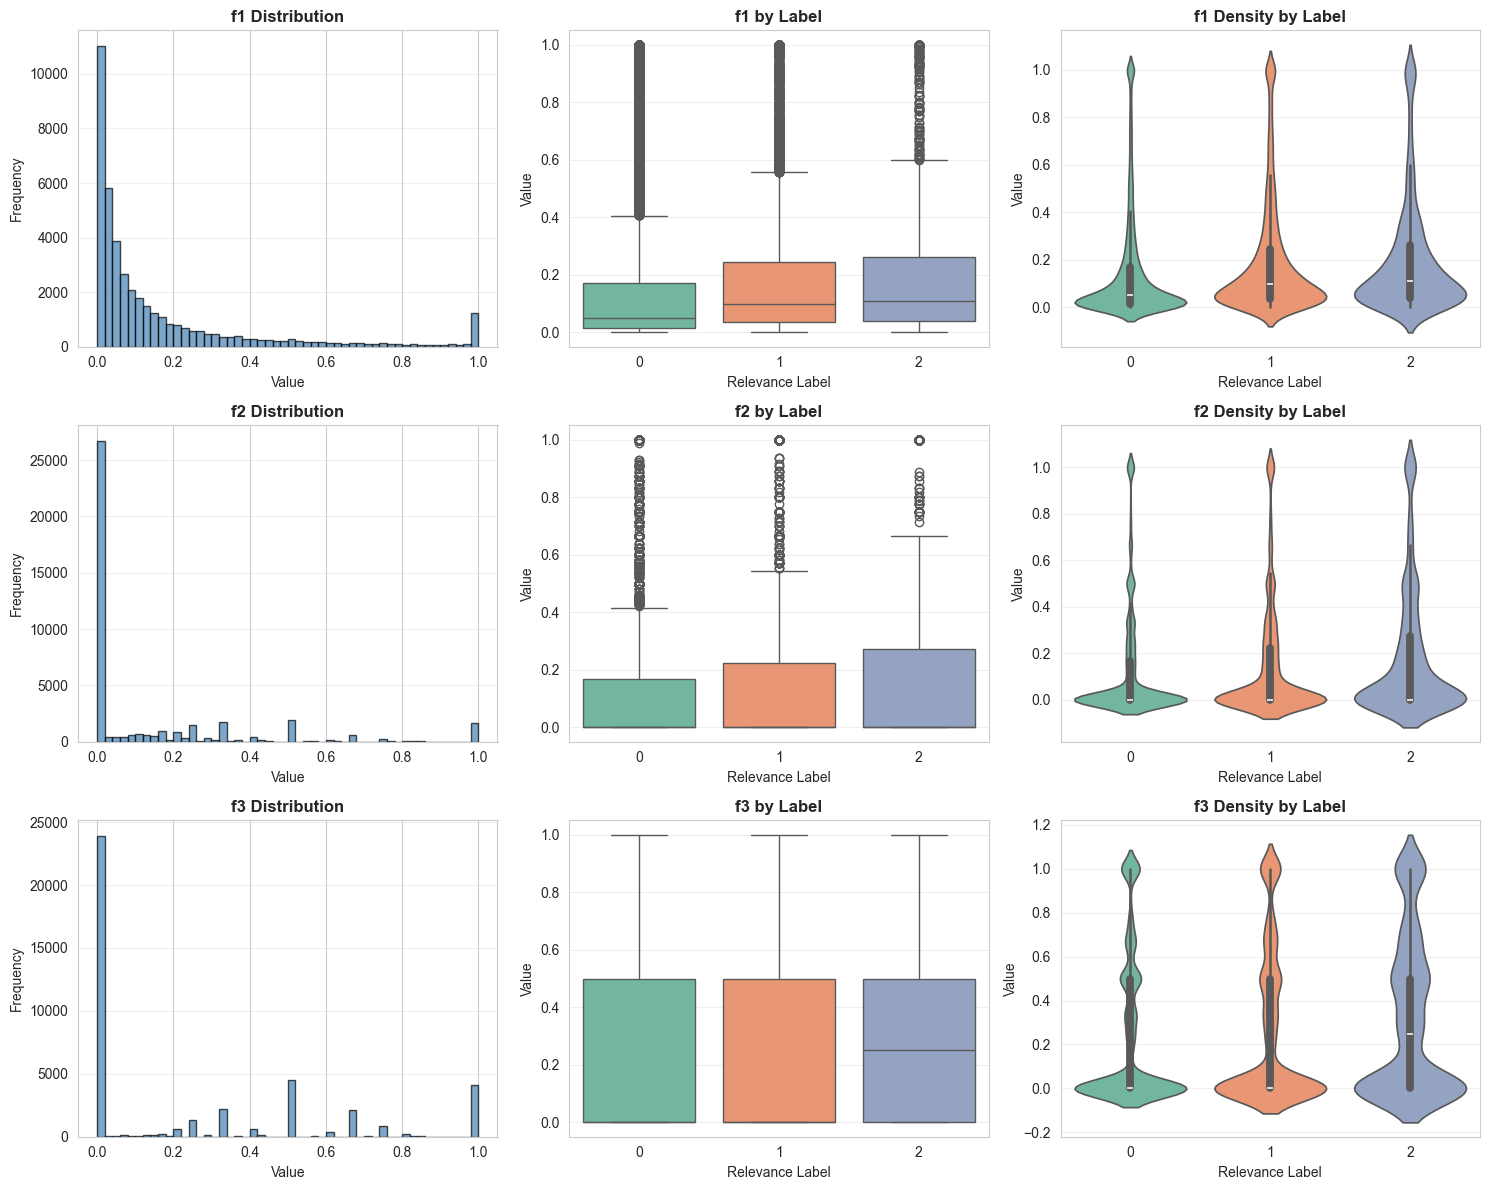


 Statistics for visualized features:


,mean,std,min,max,skewness,kurtosis
f1,0.1630,0.2366,0.0000,1.0000,2.1676,4.1743
f2,0.1376,0.2495,0.0000,1.0000,2.1259,3.9610
f3,0.2520,0.3411,0.0000,1.0000,1.0490,-0.2573


In [ ]:
#Selecting diverse features for visualization
#Picking featuers with different variance levels


low_var_feat=feature_stats.nsmallest(5,'variance').index[-1] if len(feature_stats) >= 5 else feature_cols[0]
#Picking the largest [-1] among the 5 smallest variances.
mid_var_feat=feature_stats.iloc[len(feature_stats)//2]['variance']
mid_var_feat=feature_stats.iloc[(feature_stats['variance']-mid_var_feat).abs().argsort()[0]].name
#finds the median variance value and finds the feature closest to that variance
#This is the "typical" feature - the baseline (a reference point for comparison, not a gold-standard feature)
high_var_feat=feature_stats.nlargest(5, 'variance').index[0]
#Taking the smallest of the largest 5 variances

sample_features=[low_var_feat, mid_var_feat, high_var_feat]
sample_features=[f for f in sample_features if f not in zero_var_features]

if len(sample_features)<3:
    #Fallback to first 3 non-zero-variance features
    sample_features=[f for f in feature_cols[:6] if f not in zero_var_features][:3] #Avoiding dead features

print(f"Visualizing sample features: {sample_features}")

fig, axes=plt.subplots(3,3, figsize=(15,12))

for idx, feat in enumerate(sample_features):
    #Histogram of feature values
    axes[idx,0].hist(df[feat], bins=50, color='steelblue',edgecolor='black', alpha=0.7)
    axes[idx,0].set_xlabel('Value')
    axes[idx,0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{feat} Distribution', fontweight='bold')
    axes[idx, 0].grid(axis='y', alpha=0.3)

    #Box plot by label
    df_plot=df[['label',feat]].copy()
    labels_present=df_plot['label'].unique()
    sns.boxplot(data=df_plot, x='label', y=feat, ax=axes[idx,1], palette='Set2')
    axes[idx, 1].set_xlabel('Relevance Label')
    axes[idx, 1].set_ylabel('Value')
    axes[idx, 1].set_title(f'{feat} by Label', fontweight='bold')
    axes[idx, 1].grid(axis='y', alpha=0.3)

    #Violin plot by label
    sns.violinplot(data=df_plot, x='label',y=feat, ax=axes[idx,2], palette='Set2')
    axes[idx, 2].set_xlabel('Relevance Label')
    axes[idx, 2].set_ylabel('Value')
    axes[idx, 2].set_title(f'{feat} Density by Label', fontweight='bold')
    axes[idx, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Print statistics for these features
print(f"\n Statistics for visualized features:")
display(feature_stats.loc[sample_features, ['mean','std','min','max','skewness','kurtosis']])

f1 (top row) shows heavily right-skewed histogram containing many small values. The Boxplot shows medians increase from label 0->1->2. The violin plot shows that there is higher density at larger values for label 2. We can see useful ranking signal. 

Similarly, f2:
hist-> extremely sparse
boxplot: large overlap between labels
violin: weak separation
i.e. sparse and weakly discriminative

f3:
hist: multi-modal
boxplot: some separation but not overlap
violin: label 2 shifted higher but noisy
i.e. moderate variance, moderate usefulness

## 3.2 Feature Behavior Across Relevance Labels

Analyzing how features differ between relevant and irrelevant documents.

In [23]:
print('\n'+"="*60)
print("Feature behavior across relevance labels")
print("="*60)

#computing statistics by label
label_stats={}
for label in sorted(df['label'].unique()):
    label_df=df[df['label']==label]
    label_stats[label]=label_df[feature_cols].mean()

#creating dataframe of means by label
means_by_label=pd.DataFrame(label_stats).T
means_by_label.index.name='label'

#identifying features with largest difference between relevant and irrelevant
if 0 in means_by_label.index and 2 in means_by_label.index:
    diff_irrelevant_to_highly=(means_by_label.loc[2]-means_by_label.loc[0]).abs()
    top_discriminative=diff_irrelevant_to_highly.nlargest(10)

    print(f"\nTop 10 features with largest difference between irrelevant (0) and highly relevant (2):")
    for feat, diff in top_discriminative.items():
        print(f"{feat}:{diff:.4f}(label 0 mean: {means_by_label.loc[0, feat]:.4f},"
              f"label 2 mean:{means_by_label.loc[2,feat]:.4f})")
        
    print(f"\nThese featurs show strong discriminative power between relevance levels")
    print(f"They are likely to be important for ranking models")



Feature behavior across relevance labels

Top 10 features with largest difference between irrelevant (0) and highly relevant (2):
f23:0.1803(label 0 mean: 0.5213,label 2 mean:0.7016)
f39:0.1782(label 0 mean: 0.5267,label 2 mean:0.7049)
f21:0.1570(label 0 mean: 0.5978,label 2 mean:0.7548)
f37:0.1526(label 0 mean: 0.6037,label 2 mean:0.7563)
f40:0.1350(label 0 mean: 0.5258,label 2 mean:0.6608)
f38:0.1255(label 0 mean: 0.5439,label 2 mean:0.6694)
f24:0.1252(label 0 mean: 0.5232,label 2 mean:0.6484)
f22:0.1240(label 0 mean: 0.5435,label 2 mean:0.6675)
f25:0.1024(label 0 mean: 0.1946,label 2 mean:0.2970)
f31:0.0971(label 0 mean: 0.2121,label 2 mean:0.3092)

These featurs show strong discriminative power between relevance levels
They are likely to be important for ranking models


## 3.3 Correlation Heatmap (Sample Features)

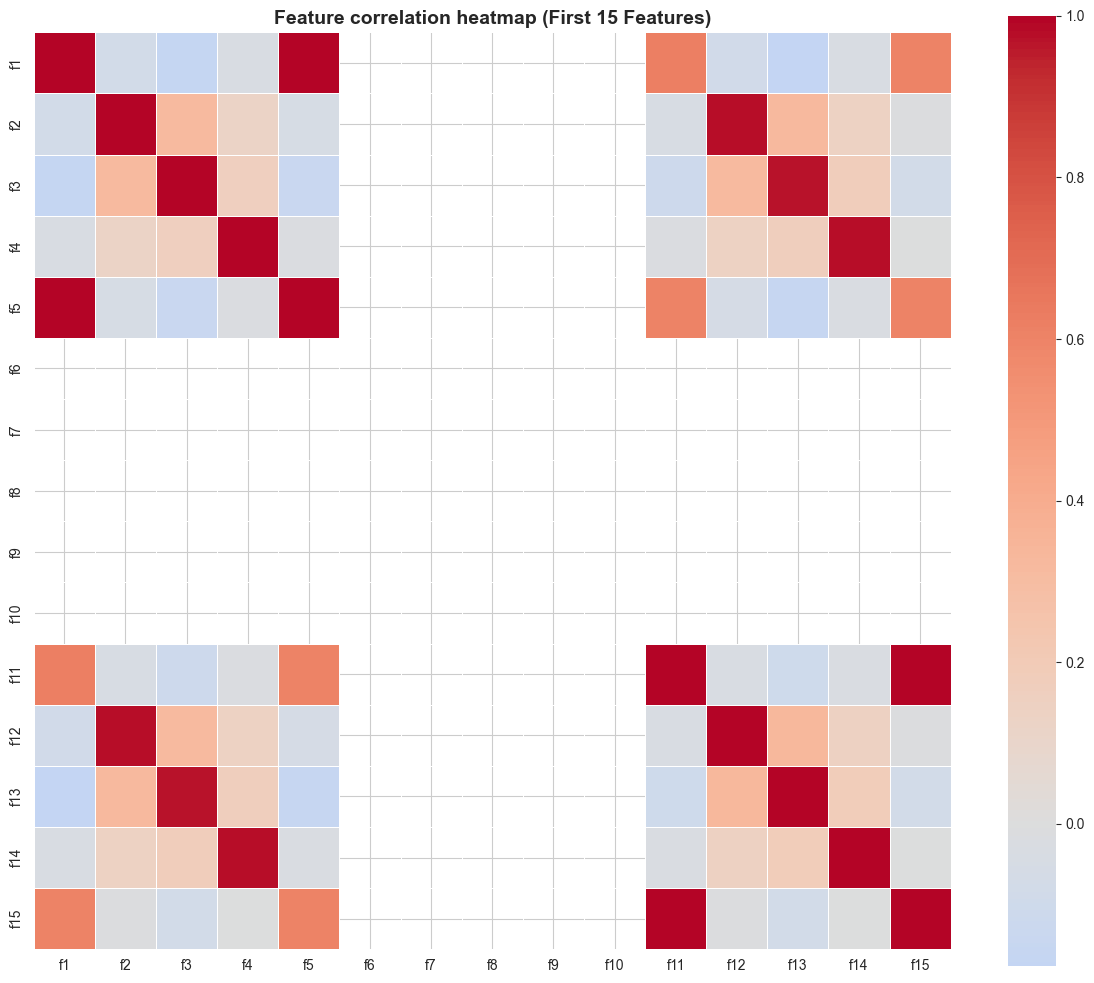


Highly correlated feature pairs (|r|>0.9):
f1-f5:0.9956
f2-f12:0.9814
f3-f13:0.9718
f4-f14:0.9728
f11-f15:0.9959

Note: Highly correlated features may cause multicollinearity in some models


In [25]:
#computing correlation for a sample of features (to keep the visualization readable)
sample_size=min(15,num_features)
sample_feats=feature_cols[:sample_size]

corr_matrix=df[sample_feats].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, square=True, linewidth=0.5)
plt.title(f"Feature correlation heatmap (First {sample_size} Features)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#Identify highly correlated pairs
high_corr_threshold=0.9
high_corr_pairs=[]
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>high_corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))
        
    
if high_corr_pairs:
    print(f"\nHighly correlated feature pairs (|r|>{high_corr_threshold}):")
    for feat1, feat2,corr_val in high_corr_pairs:
        print(f"{feat1}-{feat2}:{corr_val:.4f}")
    print(f"\nNote: Highly correlated features may cause multicollinearity in some models")

else:
    print(f"\nNo highly correlated pairs found (threshold:{high_corr_threshold})")

We visualize a small subset of features just to check whether correlation is even an issue. For the full feature set, we rely on programmatic checks rather than plots. Correlation is mainly a diagnostic concern, not a primery criterion for ranking.